In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

C:\Users\x12la\AppData\Local\Temp\ipykernel_19124\3251125660.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


<h1> Load Data

In [2]:
# CMAQ lat/lon datafile
d03 = Dataset('C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc')
cmaq_lon,cmaq_lat = np.array(d03['lon']),np.array(d03['lat'])
cmaq_llat,cmaq_ulat,cmaq_llon,cmaq_ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()

In [3]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

#primary roads
primary_roads = gpd.read_file('C:/Users/x12la/Desktop/Scripts/tl_2016_us_primaryroads.shp')
primary_roads = primary_roads.to_crs('EPSG:4326')

In [4]:
locus_aconc = gpd.read_file("COMBINE_ACONC_LOCUSIdling_HDVSpatial_2023_annual_censustracts.shp").to_crs("EPSG:4326")
locus_o3    = gpd.read_file("dailymaxozone_LOCUSIdling_HDVSpatial_2023_annual_censustracts.shp").to_crs("EPSG:4326")

In [5]:
base_aconc = gpd.read_file("COMBINE_ACONC_BASE_2023_annual_censustracts.shp").to_crs("EPSG:4326")
base_o3    = gpd.read_file("dailymaxozone_base_2023_annual_censustracts.shp").to_crs("EPSG:4326")

In [6]:
cmap_domain = cmap_cty.geometry.unary_union

cmap_roads = gpd.clip(primary_roads.to_crs("EPSG:4326"), cmap_domain)

cmap_base  = gpd.clip(base_aconc, cmap_domain)
cmap_base_o3     = gpd.clip(base_o3, cmap_domain)
cmap_locus = gpd.clip(locus_aconc, cmap_domain)
cmap_locus_o3    = gpd.clip(locus_o3, cmap_domain)

In [7]:
# # # Load in NHGIS of the 2019-2023 ACS
demo_data = pd.read_csv('../demographic/nhgis0011_ds267_20235_tract.csv')

census_tracts = gpd.read_file('../demographic/cmap_census_tracts2018.shp')
census_tracts = census_tracts.to_crs('EPSG:4326')

demo_joined = census_tracts.merge(demo_data, on='GISJOIN')
domain_tracts = gpd.clip(census_tracts, cmap_cty.to_crs('EPSG:4326'))
domain_demo   = gpd.clip(demo_joined,  cmap_cty.to_crs('EPSG:4326'))

In [8]:
benmap_df = pd.read_csv("BenMAP_Ready_USALEEP_AllCauseRates_OriginalYears.csv")
#benmap_df = pd.read_csv("../demographic/BenMAP_Ready_Tract_Incidence_CountyRatio_Edited.csv")

In [9]:
benmap_df.head()

,Endpoint Group,Endpoint,Race,Gender,Ethnicity,Start Age,End Age,TractFIPS,StateCountyFIPS,Type,Value
0,Mortality,"Mortality, All Cause",NaN,NaN,NaN,0,0,20100,1001,Incidence,0.020097
1,Mortality,"Mortality, All Cause",NaN,NaN,NaN,1,4,20100,1001,Incidence,0.002231
2,Mortality,"Mortality, All Cause",NaN,NaN,NaN,5,14,20100,1001,Incidence,0.000619
3,Mortality,"Mortality, All Cause",NaN,NaN,NaN,15,24,20100,1001,Incidence,0.000865
4,Mortality,"Mortality, All Cause",NaN,NaN,NaN,25,34,20100,1001,Incidence,0.002421


<h1> Data formatting 

In [10]:
benmap_df["StateCountyFIPS_v1"] = benmap_df["StateCountyFIPS"].astype(str).str.zfill(5)
benmap_df["TractFIPS_v1"] = benmap_df["TractFIPS"].astype(str).str.zfill(6)

# Use this if domain_demo/cmap_* GEOID values include "14000US"
benmap_df["GEOID"] =  benmap_df["StateCountyFIPS_v1"] + benmap_df["TractFIPS_v1"]

# Use this instead if your GEOID values are only 11-digit FIPS
# benmap_df["GEOID"] = benmap_df["StateCountyFIPS_v1"] + benmap_df["TractFIPS_v1"]

bmr_age_bins = {
    "0-0": "BMR_0_0",
    "1-4": "BMR_1_4",
    "5-14": "BMR_5_14",
    "15-24": "BMR_15_24",
    "25-34": "BMR_25_34",
    "35-44": "BMR_35_44",
    "45-54": "BMR_45_54",
    "55-64": "BMR_55_64",
    "65-74": "BMR_65_74",
    "75-84": "BMR_75_84",
    "85-99": "BMR_85_99",
}

benmap_df["AgeBin"] = (
    benmap_df["Start Age"].astype(str) + "-" + benmap_df["End Age"].astype(str)
)

benmap_df["BMR_Column"] = benmap_df["AgeBin"].map(bmr_age_bins)
benmap_df = benmap_df.dropna(subset=["BMR_Column"])

bmr_wide_df = (
    benmap_df
    .pivot_table(
        index="GEOID",
        columns="BMR_Column",
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

bmr_wide_df = bmr_wide_df[
    ["GEOID"] + sorted([col for col in bmr_wide_df.columns if col != "GEOID"])
]

In [11]:
pollutants = ["NO2", "PM25_EC", "PM25_TOT"]

base_pollutants = cmap_base[["GEOID"] + pollutants].copy()
base_pollutants = base_pollutants.rename(
    columns={col: f"base_{col}" for col in pollutants}
)

locus_pollutants = cmap_locus[["GEOID"] + pollutants].copy()
locus_pollutants = locus_pollutants.rename(
    columns={col: f"locus_{col}" for col in pollutants}
)

base_o3_col = cmap_base_o3[["GEOID", "O3"]].copy()
base_o3_col = base_o3_col.rename(columns={"O3": "base_O3"})

locus_o3_col = cmap_locus_o3[["GEOID", "O3"]].copy()
locus_o3_col = locus_o3_col.rename(columns={"O3": "locus_O3"})

aq_scenarios = (
    base_pollutants
    .merge(locus_pollutants, on="GEOID", how="inner")
    .merge(base_o3_col, on="GEOID", how="inner")
    .merge(locus_o3_col, on="GEOID", how="inner")
)

full_merged = (
    domain_demo
    .merge(aq_scenarios, on="GEOID", how="inner")
    .merge(bmr_wide_df, on="GEOID", how="inner")
)

full_merged

,GISJOIN,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,BMR_15_24,BMR_1_4,BMR_25_34,BMR_35_44,BMR_45_54,BMR_55_64,BMR_5_14,BMR_65_74,BMR_75_84,BMR_85_99
0,G1700910010900,17,091,010900,17091010900,109,Census Tract 109,G5020,S,189425605.0,...,0.000923,0.000226,0.001784,0.001916,0.007119,0.010016,0.000125,0.016647,0.042583,0.124401
1,G1800890043401,18,089,043401,18089043401,434.01,Census Tract 434.01,G5020,S,160485773.0,...,0.000397,0.000227,0.000988,0.001073,0.002360,0.009373,0.000123,0.019890,0.062501,0.191983
2,G1701970883902,17,197,883902,17197883902,8839.02,Census Tract 8839.02,G5020,S,116132140.0,...,0.001283,0.000211,0.000929,0.000853,0.002451,0.007468,0.000203,0.017051,0.054653,0.144738
3,G1701970883808,17,197,883808,17197883808,8838.08,Census Tract 8838.08,G5020,S,30930415.0,...,0.000491,0.000135,0.000789,0.000873,0.002193,0.006267,0.000135,0.016378,0.047602,0.145780
4,G1701970883811,17,197,883811,17197883811,8838.11,Census Tract 8838.11,G5020,S,23262854.0,...,0.001339,0.000162,0.001200,0.000531,0.003081,0.007070,0.000088,0.018483,0.085030,0.252770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1932,G1700970861012,17,097,861012,17097861012,8610.12,Census Tract 8610.12,G5020,S,14845555.0,...,0.000369,0.000134,0.000574,0.001724,0.002265,0.006222,0.000078,0.015847,0.048374,0.172071
1933,G1700970860809,17,097,860809,17097860809,8608.09,Census Tract 8608.09,G5020,S,8400459.0,...,0.000606,0.000129,0.000964,0.000870,0.002465,0.003091,0.000076,0.007860,0.039473,0.179613
1934,G1700970860811,17,097,860811,17097860811,8608.11,Census Tract 8608.11,G5020,S,17538320.0,...,0.000920,0.000143,0.001710,0.000240,0.002647,0.005310,0.000088,0.014616,0.049938,0.392590
1935,G1700970860806,17,097,860806,17097860806,8608.06,Census Tract 8608.06,G5020,S,5128895.0,...,0.000260,0.000141,0.001236,0.000699,0.002935,0.006124,0.000076,0.023256,0.049618,0.219332


In [12]:
# population data 
male_population_columns = {
    "Under 5 years": "ASNQE003",
    "5 to 9 years": "ASNQE004",
    "10 to 14 years": "ASNQE005",
    "15 to 17 years": "ASNQE006",
    "18 and 19 years": "ASNQE007",
    "20 years": "ASNQE008",
    "21 years": "ASNQE009",
    "22 to 24 years": "ASNQE010",
    "25 to 29 years": "ASNQE011",
    "30 to 34 years": "ASNQE012",
    "35 to 39 years": "ASNQE013",
    "40 to 44 years": "ASNQE014",
    "45 to 49 years": "ASNQE015",
    "50 to 54 years": "ASNQE016",
    "55 to 59 years": "ASNQE017",
    "60 and 61 years": "ASNQE018",
    "62 to 64 years": "ASNQE019",
    "65 and 66 years": "ASNQE020",
    "67 to 69 years": "ASNQE021",
    "70 to 74 years": "ASNQE022",
    "75 to 79 years": "ASNQE023",
    "80 to 84 years": "ASNQE024",
    "85 years and over": "ASNQE025"
}

female_population_columns = {
    "Under 5 years": "ASNQE027",
    "5 to 9 years": "ASNQE028",
    "10 to 14 years": "ASNQE029",
    "15 to 17 years": "ASNQE030",
    "18 and 19 years": "ASNQE031",
    "20 years": "ASNQE032",
    "21 years": "ASNQE033",
    "22 to 24 years": "ASNQE034",
    "25 to 29 years": "ASNQE035",
    "30 to 34 years": "ASNQE036",
    "35 to 39 years": "ASNQE037",
    "40 to 44 years": "ASNQE038",
    "45 to 49 years": "ASNQE039",
    "50 to 54 years": "ASNQE040",
    "55 to 59 years": "ASNQE041",
    "60 and 61 years": "ASNQE042",
    "62 to 64 years": "ASNQE043",
    "65 and 66 years": "ASNQE044",
    "67 to 69 years": "ASNQE045",
    "70 to 74 years": "ASNQE046",
    "75 to 79 years": "ASNQE047",
    "80 to 84 years": "ASNQE048",
    "85 years and over": "ASNQE049"
}

In [13]:
# 1. Calculate baseline mortality over age 30
# ============================================================

age_mapping = {
    "0-0": ["Under 5 years"],
    "1-4": ["Under 5 years"],
    "5-14": ["5 to 9 years", "10 to 14 years"],
    "15-24": ["15 to 17 years", "18 and 19 years", "20 years", "21 years", "22 to 24 years"],
    "25-34": ["25 to 29 years", "30 to 34 years"],
    "35-44": ["35 to 39 years", "40 to 44 years"],
    "45-54": ["45 to 49 years", "50 to 54 years"],
    "55-64": ["55 to 59 years", "60 and 61 years", "62 to 64 years"],
    "65-74": ["65 and 66 years", "67 to 69 years", "70 to 74 years"],
    "75-84": ["75 to 79 years", "80 to 84 years"],
    "85-99": ["85 years and over"]
}

for bmr_age_group, pop_age_groups in age_mapping.items():
    age_label = bmr_age_group.replace("-", "_")
    bmr_col = f"BMR_{age_label}"

    full_merged[f"BM_M_{age_label}"] = 0
    full_merged[f"BM_F_{age_label}"] = 0

    for pop_age_group in pop_age_groups:
        # Pop CT  * BMR CT 
        male_col = male_population_columns.get(pop_age_group)
        female_col = female_population_columns.get(pop_age_group)

        if male_col:
            full_merged[f"BM_M_{age_label}"] += full_merged[bmr_col] * full_merged[male_col]

        if female_col:
            full_merged[f"BM_F_{age_label}"] += full_merged[bmr_col] * full_merged[female_col]


# Only sum BMR groups where the age bin starts at 30+
over30_age_labels = ["35_44", "45_54", "55_64", "65_74", "75_84", "85_99"]

bm_male_cols = [f"BM_M_{age}" for age in over30_age_labels]
bm_female_cols = [f"BM_F_{age}" for age in over30_age_labels]

full_merged["BM_Male_Over30"] = full_merged[bm_male_cols].sum(axis=1)
full_merged["BM_Female_Over30"] = full_merged[bm_female_cols].sum(axis=1)
full_merged["BM_Total_Over30"] = (
    full_merged["BM_Male_Over30"] + full_merged["BM_Female_Over30"]
)

In [14]:
full_merged["BM_Total_Over30"]

0       37.931616
1       75.458082
2       68.189390
3       32.226805
4       69.845686
          ...    
1932    39.571359
1933    21.098213
1934    41.780773
1935    37.047315
1936    35.057270
Name: BM_Total_Over30, Length: 1937, dtype: float64

<h1> Calculate attributable mortality by scenario

In [15]:
pollutant_betas = {
    "NO2": {
        "col": "NO2",
        "beta": 0.00738,
        "lower": 0.00187,
        "upper": 0.01096,
    },
    "PM25_TOT": {
        "col": "PM25_TOT",
        "beta": 0.00591,
        "lower": 0.00199,
        "upper": 0.00784,
    },
    "PM25_EC": {
        "col": "PM25_EC",
        "beta": 0.0198,
        "lower": 0.0,
        "upper": 0.0392,
    },
    "O3_Turner2016": {
        "col": "O3",
        "beta": 0.00198,
        "lower": 0.000995,
        "upper": 0.00392,
    },
}

scenarios = ["base", "locus"]

for pollutant, info in pollutant_betas.items():
    pollutant_col = info["col"]

    for scenario in scenarios:
        conc_col = f"{scenario}_{pollutant_col}"

        af_col = f"AF_{pollutant}_{scenario}"
        af_lower_col = f"AF_{pollutant}_{scenario}_lower"
        af_upper_col = f"AF_{pollutant}_{scenario}_upper"

        crf_col = f"CRF_{pollutant}_{scenario}"
        crf_lower_col = f"CRF_{pollutant}_{scenario}_lower"
        crf_upper_col = f"CRF_{pollutant}_{scenario}_upper"

        full_merged[af_col] = 1 - np.exp(-info["beta"] * full_merged[conc_col])
        full_merged[af_lower_col] = 1 - np.exp(-info["lower"] * full_merged[conc_col])
        full_merged[af_upper_col] = 1 - np.exp(-info["upper"] * full_merged[conc_col])

        full_merged[crf_col] = full_merged["BM_Total_Over30"] * full_merged[af_col]
        full_merged[crf_lower_col] = full_merged["BM_Total_Over30"] * full_merged[af_lower_col]
        full_merged[crf_upper_col] = full_merged["BM_Total_Over30"] * full_merged[af_upper_col]

<h1> Calculate LOCUS minus baseline mortality differences

In [16]:
for pollutant in pollutant_betas.keys():

    full_merged[f"CRF_{pollutant}_locus_minus_base"] = (
        full_merged[f"CRF_{pollutant}_locus"]
        - full_merged[f"CRF_{pollutant}_base"]
    )

    full_merged[f"CRF_{pollutant}_locus_minus_base_lower"] = (
        full_merged[f"CRF_{pollutant}_locus_lower"]
        - full_merged[f"CRF_{pollutant}_base_lower"]
    )

    full_merged[f"CRF_{pollutant}_locus_minus_base_upper"] = (
        full_merged[f"CRF_{pollutant}_locus_upper"]
        - full_merged[f"CRF_{pollutant}_base_upper"]
    )

In [17]:
summary_rows = []

for pollutant in pollutant_betas.keys():

    for scenario in scenarios:
        summary_rows.append({
            "Pollutant": pollutant,
            "Metric": scenario,
            "Total": full_merged[f"CRF_{pollutant}_{scenario}"].sum(),
            "Lower": full_merged[f"CRF_{pollutant}_{scenario}_lower"].sum(),
            "Upper": full_merged[f"CRF_{pollutant}_{scenario}_upper"].sum(),
        })

    summary_rows.append({
        "Pollutant": pollutant,
        "Metric": "locus_minus_base",
        "Total": full_merged[f"CRF_{pollutant}_locus_minus_base"].sum(),
        "Lower": full_merged[f"CRF_{pollutant}_locus_minus_base_lower"].sum(),
        "Upper": full_merged[f"CRF_{pollutant}_locus_minus_base_upper"].sum(),
    })

mortality_summary = pd.DataFrame(summary_rows)

mortality_summary["Total"] = mortality_summary["Total"].round(2)
mortality_summary["Lower"] = mortality_summary["Lower"].round(2)
mortality_summary["Upper"] = mortality_summary["Upper"].round(2)

mortality_summary["Total_round10"] = (
    mortality_summary["Total"] / 10
).round() * 10

mortality_summary["Lower_round10"] = (
    mortality_summary["Lower"] / 10
).round() * 10

mortality_summary["Upper_round10"] = (
    mortality_summary["Upper"] / 10
).round() * 10

mortality_summary["Total_round10"] = mortality_summary["Total_round10"].astype(int)
mortality_summary["Lower_round10"] = mortality_summary["Lower_round10"].astype(int)
mortality_summary["Upper_round10"] = mortality_summary["Upper_round10"].astype(int)

mortality_summary

,Pollutant,Metric,Total,Lower,Upper,Total_round10,Lower_round10,Upper_round10
0,NO2,base,4288.88,1117.16,6257.35,4290,1120,6260
1,NO2,locus,4324.77,1126.56,6309.52,4320,1130,6310
2,NO2,locus_minus_base,35.89,9.40,52.17,40,10,50
3,PM25_TOT,base,4024.19,1383.26,5284.68,4020,1380,5280
4,PM25_TOT,locus,4023.26,1382.93,5283.49,4020,1380,5280
5,PM25_TOT,locus_minus_base,-0.92,-0.33,-1.19,0,0,0
6,PM25_EC,base,539.58,0.00,1063.77,540,0,1060
7,PM25_EC,locus,535.98,0.00,1056.71,540,0,1060
8,PM25_EC,locus_minus_base,-3.61,0.00,-7.06,0,0,-10
9,O3_Turner2016,base,5692.75,2924.09,10799.90,5690,2920,10800


<h1> Population Weighted Exposure 
    
    
<h3>
$$
\text{Domain Total Population Weighted Average Concentrations} = \frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Population Total}_{\text{CT}})}{\sum (\text{Population Total}_{\text{CT}})}
$$

<h3>
$$
\text{Subgroup Population Weighted Average Concentrations} = \frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Subgroup Population Total}_{\text{CT}})}{\sum (\text{Subgroup Population Total}_{\text{CT}})}
$$    
    

<h3>
$$
\text{Relative Concentrations Disparity} = \frac{(
\frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Subgroup Population Total}_{\text{CT}})}{\sum (\text{Subgroup Population Total}_{\text{CT}})})
}{
(\frac{\sum (\text{Concentrations}_{\text{CT}} \times \text{Population Total}_{\text{CT}})}{\sum (\text{Population Total}_{\text{CT}})})
}
$$


In [18]:
cmap_base['MDA8O3'] = cmap_base_o3['O3']
cmap_locus['MDA8O3'] = cmap_locus_o3['O3']

In [19]:
base_joined = domain_demo.merge(cmap_base, on='GISJOIN', how='inner')
locus_joined = domain_demo.merge(cmap_locus, on='GISJOIN', how='inner')

In [20]:
base_joined['OTHER_POP'] = (
    base_joined['ASOAE001'] - (
        base_joined['ASOAE003'] +   # NH White
        base_joined['ASOAE004'] +   # NH Black
        base_joined['ASOAE006'] +   # NH Asian
        base_joined['ASOAE012']     # Hispanic any race
    )
)

locus_joined['OTHER_POP'] = (
    locus_joined['ASOAE001'] - (
        locus_joined['ASOAE003'] +
        locus_joined['ASOAE004'] +
        locus_joined['ASOAE006'] +
        locus_joined['ASOAE012']
    )
)

In [21]:
base_joined['PopWeightedNO2'] = (base_joined['NO2'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
locus_joined['PopWeightedNO2'] = (locus_joined['NO2'] * locus_joined['ASOAE001']).sum() / locus_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_PopWeightedNO2'] = (df['NO2'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedNO2'] = (df['NO2'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedNO2'] = (df['NO2'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedNO2'] = (df['NO2'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedNO2'] = (df['NO2'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative disparities
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_RelNO2'] = df['White_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Black_RelNO2'] = df['Black_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Hispanic_RelNO2'] = df['Hispanic_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Asian_RelNO2'] = df['Asian_PopWeightedNO2'] / df['PopWeightedNO2']
    df['Other_RelNO2'] = df['Other_PopWeightedNO2'] / df['PopWeightedNO2']

# ------------------------------------------------------------
# absolute disparities
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_AbsNO2'] = df['White_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Black_AbsNO2'] = df['Black_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Hispanic_AbsNO2'] = df['Hispanic_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Asian_AbsNO2'] = df['Asian_PopWeightedNO2'] - df['PopWeightedNO2']
    df['Other_AbsNO2'] = df['Other_PopWeightedNO2'] - df['PopWeightedNO2']

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
no2_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedNO2'].iloc[0], base_joined['White_PopWeightedNO2'].iloc[0], base_joined['Black_PopWeightedNO2'].iloc[0], base_joined['Hispanic_PopWeightedNO2'].iloc[0], base_joined['Asian_PopWeightedNO2'].iloc[0], base_joined['Other_PopWeightedNO2'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelNO2'].iloc[0], base_joined['Black_RelNO2'].iloc[0], base_joined['Hispanic_RelNO2'].iloc[0], base_joined['Asian_RelNO2'].iloc[0], base_joined['Other_RelNO2'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsNO2'].iloc[0], base_joined['Black_AbsNO2'].iloc[0], base_joined['Hispanic_AbsNO2'].iloc[0], base_joined['Asian_AbsNO2'].iloc[0], base_joined['Other_AbsNO2'].iloc[0]],

    'Idling_PopWeighted'  : [locus_joined['PopWeightedNO2'].iloc[0], locus_joined['White_PopWeightedNO2'].iloc[0], locus_joined['Black_PopWeightedNO2'].iloc[0], locus_joined['Hispanic_PopWeightedNO2'].iloc[0], locus_joined['Asian_PopWeightedNO2'].iloc[0], locus_joined['Other_PopWeightedNO2'].iloc[0]],
    'Idling_Relative'     : [1.0, locus_joined['White_RelNO2'].iloc[0], locus_joined['Black_RelNO2'].iloc[0], locus_joined['Hispanic_RelNO2'].iloc[0], locus_joined['Asian_RelNO2'].iloc[0], locus_joined['Other_RelNO2'].iloc[0]],
    'Idling_Absolute'     : [0.0, locus_joined['White_AbsNO2'].iloc[0], locus_joined['Black_AbsNO2'].iloc[0], locus_joined['Hispanic_AbsNO2'].iloc[0], locus_joined['Asian_AbsNO2'].iloc[0], locus_joined['Other_AbsNO2'].iloc[0]],

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("=== NO2 Summary ===")
print(no2_summary.round(6).to_string())



=== NO2 Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute
Total             9.051196       1.000000       0.000000            9.087728         1.000000         0.000000
White             8.201907       0.906168      -0.849290            8.206743         0.903058        -0.880985
Black            10.346343       1.143091       1.295147           10.457266         1.150702         1.369539
Hispanic          9.796146       1.082304       0.744950            9.899646         1.089342         0.811919
Asian             9.281596       1.025455       0.230399            9.164934         1.008496         0.077206
Other             8.891218       0.982325      -0.159978            8.856440         0.974550        -0.231287


In [22]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedPM25_TOT'] = (base_joined['PM25_TOT'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
locus_joined['PopWeightedPM25_TOT'] = (locus_joined['PM25_TOT'] * locus_joined['ASOAE001']).sum() / locus_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedPM25_TOT'] = (df['PM25_TOT'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative disparities
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_RelPM25_TOT'] = df['White_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Black_RelPM25_TOT'] = df['Black_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Hispanic_RelPM25_TOT'] = df['Hispanic_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Asian_RelPM25_TOT'] = df['Asian_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']
    df['Other_RelPM25_TOT'] = df['Other_PopWeightedPM25_TOT'] / df['PopWeightedPM25_TOT']

# ------------------------------------------------------------
# absolute disparities
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_AbsPM25_TOT'] = df['White_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Black_AbsPM25_TOT'] = df['Black_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Hispanic_AbsPM25_TOT'] = df['Hispanic_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Asian_AbsPM25_TOT'] = df['Asian_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']
    df['Other_AbsPM25_TOT'] = df['Other_PopWeightedPM25_TOT'] - df['PopWeightedPM25_TOT']

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
pm25_tot_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedPM25_TOT'].iloc[0], base_joined['White_PopWeightedPM25_TOT'].iloc[0], base_joined['Black_PopWeightedPM25_TOT'].iloc[0], base_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], base_joined['Asian_PopWeightedPM25_TOT'].iloc[0], base_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelPM25_TOT'].iloc[0], base_joined['Black_RelPM25_TOT'].iloc[0], base_joined['Hispanic_RelPM25_TOT'].iloc[0], base_joined['Asian_RelPM25_TOT'].iloc[0], base_joined['Other_RelPM25_TOT'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsPM25_TOT'].iloc[0], base_joined['Black_AbsPM25_TOT'].iloc[0], base_joined['Hispanic_AbsPM25_TOT'].iloc[0], base_joined['Asian_AbsPM25_TOT'].iloc[0], base_joined['Other_AbsPM25_TOT'].iloc[0]],

    'Idling_PopWeighted'  : [locus_joined['PopWeightedPM25_TOT'].iloc[0], locus_joined['White_PopWeightedPM25_TOT'].iloc[0], locus_joined['Black_PopWeightedPM25_TOT'].iloc[0], locus_joined['Hispanic_PopWeightedPM25_TOT'].iloc[0], locus_joined['Asian_PopWeightedPM25_TOT'].iloc[0], locus_joined['Other_PopWeightedPM25_TOT'].iloc[0]],
    'Idling_Relative'     : [1.0, locus_joined['White_RelPM25_TOT'].iloc[0], locus_joined['Black_RelPM25_TOT'].iloc[0], locus_joined['Hispanic_RelPM25_TOT'].iloc[0], locus_joined['Asian_RelPM25_TOT'].iloc[0], locus_joined['Other_RelPM25_TOT'].iloc[0]],
    'Idling_Absolute'     : [0.0, locus_joined['White_AbsPM25_TOT'].iloc[0], locus_joined['Black_AbsPM25_TOT'].iloc[0], locus_joined['Hispanic_AbsPM25_TOT'].iloc[0], locus_joined['Asian_AbsPM25_TOT'].iloc[0], locus_joined['Other_AbsPM25_TOT'].iloc[0]],

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("\n=== PM25_TOT Summary ===")
print(pm25_tot_summary.round(6).to_string())


=== PM25_TOT Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute
Total            10.517891       1.000000       0.000000           10.512787         1.000000         0.000000
White            10.209430       0.970673      -0.308461           10.201635         0.970403        -0.311151
Black            11.026519       1.048358       0.508628           11.025157         1.048738         0.512371
Hispanic         10.818048       1.028538       0.300156           10.819507         1.029176         0.306720
Asian            10.425356       0.991202      -0.092535           10.409863         0.990210        -0.102923
Other            10.439314       0.992529      -0.078577           10.428440         0.991977        -0.084346


In [23]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedPM25_EC'] = (base_joined['PM25_EC'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
locus_joined['PopWeightedPM25_EC'] = (locus_joined['PM25_EC'] * locus_joined['ASOAE001']).sum() / locus_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedPM25_EC'] = (df['PM25_EC'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative disparities
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_RelPM25_EC'] = df['White_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Black_RelPM25_EC'] = df['Black_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Hispanic_RelPM25_EC'] = df['Hispanic_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Asian_RelPM25_EC'] = df['Asian_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']
    df['Other_RelPM25_EC'] = df['Other_PopWeightedPM25_EC'] / df['PopWeightedPM25_EC']

# ------------------------------------------------------------
# absolute disparities
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_AbsPM25_EC'] = df['White_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Black_AbsPM25_EC'] = df['Black_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Hispanic_AbsPM25_EC'] = df['Hispanic_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Asian_AbsPM25_EC'] = df['Asian_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']
    df['Other_AbsPM25_EC'] = df['Other_PopWeightedPM25_EC'] - df['PopWeightedPM25_EC']

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
pm25_ec_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedPM25_EC'].iloc[0], base_joined['White_PopWeightedPM25_EC'].iloc[0], base_joined['Black_PopWeightedPM25_EC'].iloc[0], base_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], base_joined['Asian_PopWeightedPM25_EC'].iloc[0], base_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelPM25_EC'].iloc[0], base_joined['Black_RelPM25_EC'].iloc[0], base_joined['Hispanic_RelPM25_EC'].iloc[0], base_joined['Asian_RelPM25_EC'].iloc[0], base_joined['Other_RelPM25_EC'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsPM25_EC'].iloc[0], base_joined['Black_AbsPM25_EC'].iloc[0], base_joined['Hispanic_AbsPM25_EC'].iloc[0], base_joined['Asian_AbsPM25_EC'].iloc[0], base_joined['Other_AbsPM25_EC'].iloc[0]],

    'Idling_PopWeighted'  : [locus_joined['PopWeightedPM25_EC'].iloc[0], locus_joined['White_PopWeightedPM25_EC'].iloc[0], locus_joined['Black_PopWeightedPM25_EC'].iloc[0], locus_joined['Hispanic_PopWeightedPM25_EC'].iloc[0], locus_joined['Asian_PopWeightedPM25_EC'].iloc[0], locus_joined['Other_PopWeightedPM25_EC'].iloc[0]],
    'Idling_Relative'     : [1.0, locus_joined['White_RelPM25_EC'].iloc[0], locus_joined['Black_RelPM25_EC'].iloc[0], locus_joined['Hispanic_RelPM25_EC'].iloc[0], locus_joined['Asian_RelPM25_EC'].iloc[0], locus_joined['Other_RelPM25_EC'].iloc[0]],
    'Idling_Absolute'     : [0.0, locus_joined['White_AbsPM25_EC'].iloc[0], locus_joined['Black_AbsPM25_EC'].iloc[0], locus_joined['Hispanic_AbsPM25_EC'].iloc[0], locus_joined['Asian_AbsPM25_EC'].iloc[0], locus_joined['Other_AbsPM25_EC'].iloc[0]],

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("\n=== PM25_EC Summary ===")
print(pm25_ec_summary.round(6).to_string())


=== PM25_EC Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute
Total             0.411404       1.000000       0.000000            0.406834         1.000000         0.000000
White             0.381220       0.926631      -0.030184            0.375957         0.924106        -0.030876
Black             0.454118       1.103826       0.042714            0.452270         1.111684         0.045437
Hispanic          0.440714       1.071244       0.029310            0.437797         1.076108         0.030963
Asian             0.417949       1.015908       0.006545            0.407357         1.001286         0.000523
Other             0.404405       0.982989      -0.006999            0.397336         0.976655        -0.009497


In [24]:
# ------------------------------------------------------------
# overall population-weighted concentration
# ------------------------------------------------------------
base_joined['PopWeightedO3'] = (base_joined['O3'] * base_joined['ASOAE001']).sum() / base_joined['ASOAE001'].sum()
locus_joined['PopWeightedO3'] = (locus_joined['O3'] * locus_joined['ASOAE001']).sum() / locus_joined['ASOAE001'].sum()

# ------------------------------------------------------------
# subgroup population-weighted concentration
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_PopWeightedO3'] = (df['O3'] * df['ASOAE003']).sum() / df['ASOAE003'].sum()
    df['Black_PopWeightedO3'] = (df['O3'] * df['ASOAE004']).sum() / df['ASOAE004'].sum()
    df['Hispanic_PopWeightedO3'] = (df['O3'] * df['ASOAE012']).sum() / df['ASOAE012'].sum()
    df['Asian_PopWeightedO3'] = (df['O3'] * df['ASOAE006']).sum() / df['ASOAE006'].sum()
    df['Other_PopWeightedO3'] = (df['O3'] * df['OTHER_POP']).sum() / df['OTHER_POP'].sum()

# ------------------------------------------------------------
# relative disparities
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_RelO3'] = df['White_PopWeightedO3'] / df['PopWeightedO3']
    df['Black_RelO3'] = df['Black_PopWeightedO3'] / df['PopWeightedO3']
    df['Hispanic_RelO3'] = df['Hispanic_PopWeightedO3'] / df['PopWeightedO3']
    df['Asian_RelO3'] = df['Asian_PopWeightedO3'] / df['PopWeightedO3']
    df['Other_RelO3'] = df['Other_PopWeightedO3'] / df['PopWeightedO3']

# ------------------------------------------------------------
# absolute disparities
# ------------------------------------------------------------
for df in [base_joined, locus_joined]:
    df['White_AbsO3'] = df['White_PopWeightedO3'] - df['PopWeightedO3']
    df['Black_AbsO3'] = df['Black_PopWeightedO3'] - df['PopWeightedO3']
    df['Hispanic_AbsO3'] = df['Hispanic_PopWeightedO3'] - df['PopWeightedO3']
    df['Asian_AbsO3'] = df['Asian_PopWeightedO3'] - df['PopWeightedO3']
    df['Other_AbsO3'] = df['Other_PopWeightedO3'] - df['PopWeightedO3']


# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------
O3_summary = pd.DataFrame({
    'Base_PopWeighted'    : [base_joined['PopWeightedO3'].iloc[0], base_joined['White_PopWeightedO3'].iloc[0], base_joined['Black_PopWeightedO3'].iloc[0], base_joined['Hispanic_PopWeightedO3'].iloc[0], base_joined['Asian_PopWeightedO3'].iloc[0], base_joined['Other_PopWeightedO3'].iloc[0]],
    'Base_Relative'       : [1.0, base_joined['White_RelO3'].iloc[0], base_joined['Black_RelO3'].iloc[0], base_joined['Hispanic_RelO3'].iloc[0], base_joined['Asian_RelO3'].iloc[0], base_joined['Other_RelO3'].iloc[0]],
    'Base_Absolute'       : [0.0, base_joined['White_AbsO3'].iloc[0], base_joined['Black_AbsO3'].iloc[0], base_joined['Hispanic_AbsO3'].iloc[0], base_joined['Asian_AbsO3'].iloc[0], base_joined['Other_AbsO3'].iloc[0]],

    'Idling_PopWeighted'  : [locus_joined['PopWeightedO3'].iloc[0], locus_joined['White_PopWeightedO3'].iloc[0], locus_joined['Black_PopWeightedO3'].iloc[0], locus_joined['Hispanic_PopWeightedO3'].iloc[0], locus_joined['Asian_PopWeightedO3'].iloc[0], locus_joined['Other_PopWeightedO3'].iloc[0]],
    'Idling_Relative'     : [1.0, locus_joined['White_RelO3'].iloc[0], locus_joined['Black_RelO3'].iloc[0], locus_joined['Hispanic_RelO3'].iloc[0], locus_joined['Asian_RelO3'].iloc[0], locus_joined['Other_RelO3'].iloc[0]],
    'Idling_Absolute'     : [0.0, locus_joined['White_AbsO3'].iloc[0], locus_joined['Black_AbsO3'].iloc[0], locus_joined['Hispanic_AbsO3'].iloc[0], locus_joined['Asian_AbsO3'].iloc[0], locus_joined['Other_AbsO3'].iloc[0]],

}, index=['Total','White','Black','Hispanic','Asian','Other'])

print("\n=== O3 Summary ===")
print(O3_summary.round(6).to_string())


=== O3 Summary ===
          Base_PopWeighted  Base_Relative  Base_Absolute  Idling_PopWeighted  Idling_Relative  Idling_Absolute
Total            34.063028       1.000000       0.000000           34.026842         1.000000         0.000000
White            34.596475       1.015661       0.533447           34.578502         1.016212         0.551660
Black            33.249507       0.976117      -0.813521           33.165102         0.974675        -0.861741
Hispanic         33.547191       0.984856      -0.515838           33.464698         0.983479        -0.562144
Asian            34.061201       0.999946      -0.001827           34.146534         1.003518         0.119692
Other            34.207698       1.004247       0.144670           34.224234         1.005801         0.197391


In [25]:
subgroups_for_plot = ["Total", "White", "Black", "Hispanic", "Asian", "Other"]

colors_for_plot = {
    "Total": "#d9d9d9",
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77"
}

hatches = {
    "EPA Default": "",
    "Idling and On-road Activity Modification": "//",

}

scenario_keys = ["EPA Default", "Idling and On-road Activity Modification"]
scenario_labels = ["EPA Default", "Idling and On-road Activity Modificationn"]

# ------------------------------------------------------------
# NO2
# ------------------------------------------------------------
base_no2_total = no2_summary.loc["Total", "Base_PopWeighted"]
base_no2_white = no2_summary.loc["White", "Base_PopWeighted"]
base_no2_black = no2_summary.loc["Black", "Base_PopWeighted"]
base_no2_hisp  = no2_summary.loc["Hispanic", "Base_PopWeighted"]
base_no2_asian = no2_summary.loc["Asian", "Base_PopWeighted"]
base_no2_other = no2_summary.loc["Other", "Base_PopWeighted"]

idling_no2_total = no2_summary.loc["Total", "Idling_PopWeighted"]
idling_no2_white = no2_summary.loc["White", "Idling_PopWeighted"]
idling_no2_black = no2_summary.loc["Black", "Idling_PopWeighted"]
idling_no2_hisp  = no2_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_no2_asian = no2_summary.loc["Asian", "Idling_PopWeighted"]
idling_no2_other = no2_summary.loc["Other", "Idling_PopWeighted"]

no2_vals = np.array([
    [base_no2_total,    base_no2_white,    base_no2_black,    base_no2_hisp,    base_no2_asian,    base_no2_other],
    [idling_no2_total,  idling_no2_white,  idling_no2_black,  idling_no2_hisp,  idling_no2_asian,  idling_no2_other],
    ], dtype=float)

# ------------------------------------------------------------
# PM25 total
# ------------------------------------------------------------
base_pm25tot_total = pm25_tot_summary.loc["Total", "Base_PopWeighted"]
base_pm25tot_white = pm25_tot_summary.loc["White", "Base_PopWeighted"]
base_pm25tot_black = pm25_tot_summary.loc["Black", "Base_PopWeighted"]
base_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "Base_PopWeighted"]
base_pm25tot_asian = pm25_tot_summary.loc["Asian", "Base_PopWeighted"]
base_pm25tot_other = pm25_tot_summary.loc["Other", "Base_PopWeighted"]

idling_pm25tot_total = pm25_tot_summary.loc["Total", "Idling_PopWeighted"]
idling_pm25tot_white = pm25_tot_summary.loc["White", "Idling_PopWeighted"]
idling_pm25tot_black = pm25_tot_summary.loc["Black", "Idling_PopWeighted"]
idling_pm25tot_hisp  = pm25_tot_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_pm25tot_asian = pm25_tot_summary.loc["Asian", "Idling_PopWeighted"]
idling_pm25tot_other = pm25_tot_summary.loc["Other", "Idling_PopWeighted"]

pm25tot_vals = np.array([
    [base_pm25tot_total,    base_pm25tot_white,    base_pm25tot_black,    base_pm25tot_hisp,    base_pm25tot_asian,    base_pm25tot_other],
    [idling_pm25tot_total,  idling_pm25tot_white,  idling_pm25tot_black,  idling_pm25tot_hisp,  idling_pm25tot_asian,  idling_pm25tot_other],], dtype=float)

# ------------------------------------------------------------
# PM25 EC
# ------------------------------------------------------------
base_pm25ec_total = pm25_ec_summary.loc["Total", "Base_PopWeighted"]
base_pm25ec_white = pm25_ec_summary.loc["White", "Base_PopWeighted"]
base_pm25ec_black = pm25_ec_summary.loc["Black", "Base_PopWeighted"]
base_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "Base_PopWeighted"]
base_pm25ec_asian = pm25_ec_summary.loc["Asian", "Base_PopWeighted"]
base_pm25ec_other = pm25_ec_summary.loc["Other", "Base_PopWeighted"]

idling_pm25ec_total = pm25_ec_summary.loc["Total", "Idling_PopWeighted"]
idling_pm25ec_white = pm25_ec_summary.loc["White", "Idling_PopWeighted"]
idling_pm25ec_black = pm25_ec_summary.loc["Black", "Idling_PopWeighted"]
idling_pm25ec_hisp  = pm25_ec_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_pm25ec_asian = pm25_ec_summary.loc["Asian", "Idling_PopWeighted"]
idling_pm25ec_other = pm25_ec_summary.loc["Other", "Idling_PopWeighted"]


pm25ec_vals = np.array([
    [base_pm25ec_total,    base_pm25ec_white,    base_pm25ec_black,    base_pm25ec_hisp,    base_pm25ec_asian,    base_pm25ec_other],
    [idling_pm25ec_total,  idling_pm25ec_white,  idling_pm25ec_black,  idling_pm25ec_hisp,  idling_pm25ec_asian,  idling_pm25ec_other],
   ], dtype=float)

# ------------------------------------------------------------
# O3
# ------------------------------------------------------------
base_o3_total = O3_summary.loc["Total", "Base_PopWeighted"]
base_o3_white = O3_summary.loc["White", "Base_PopWeighted"]
base_o3_black = O3_summary.loc["Black", "Base_PopWeighted"]
base_o3_hisp  = O3_summary.loc["Hispanic", "Base_PopWeighted"]
base_o3_asian = O3_summary.loc["Asian", "Base_PopWeighted"]
base_o3_other = O3_summary.loc["Other", "Base_PopWeighted"]

idling_o3_total = O3_summary.loc["Total", "Idling_PopWeighted"]
idling_o3_white = O3_summary.loc["White", "Idling_PopWeighted"]
idling_o3_black = O3_summary.loc["Black", "Idling_PopWeighted"]
idling_o3_hisp  = O3_summary.loc["Hispanic", "Idling_PopWeighted"]
idling_o3_asian = O3_summary.loc["Asian", "Idling_PopWeighted"]
idling_o3_other = O3_summary.loc["Other", "Idling_PopWeighted"]


o3_vals = np.array([
    [base_o3_total,    base_o3_white,    base_o3_black,    base_o3_hisp,    base_o3_asian,    base_o3_other],
    [idling_o3_total,  idling_o3_white,  idling_o3_black,  idling_o3_hisp,  idling_o3_asian,  idling_o3_other],
   ], dtype=float)

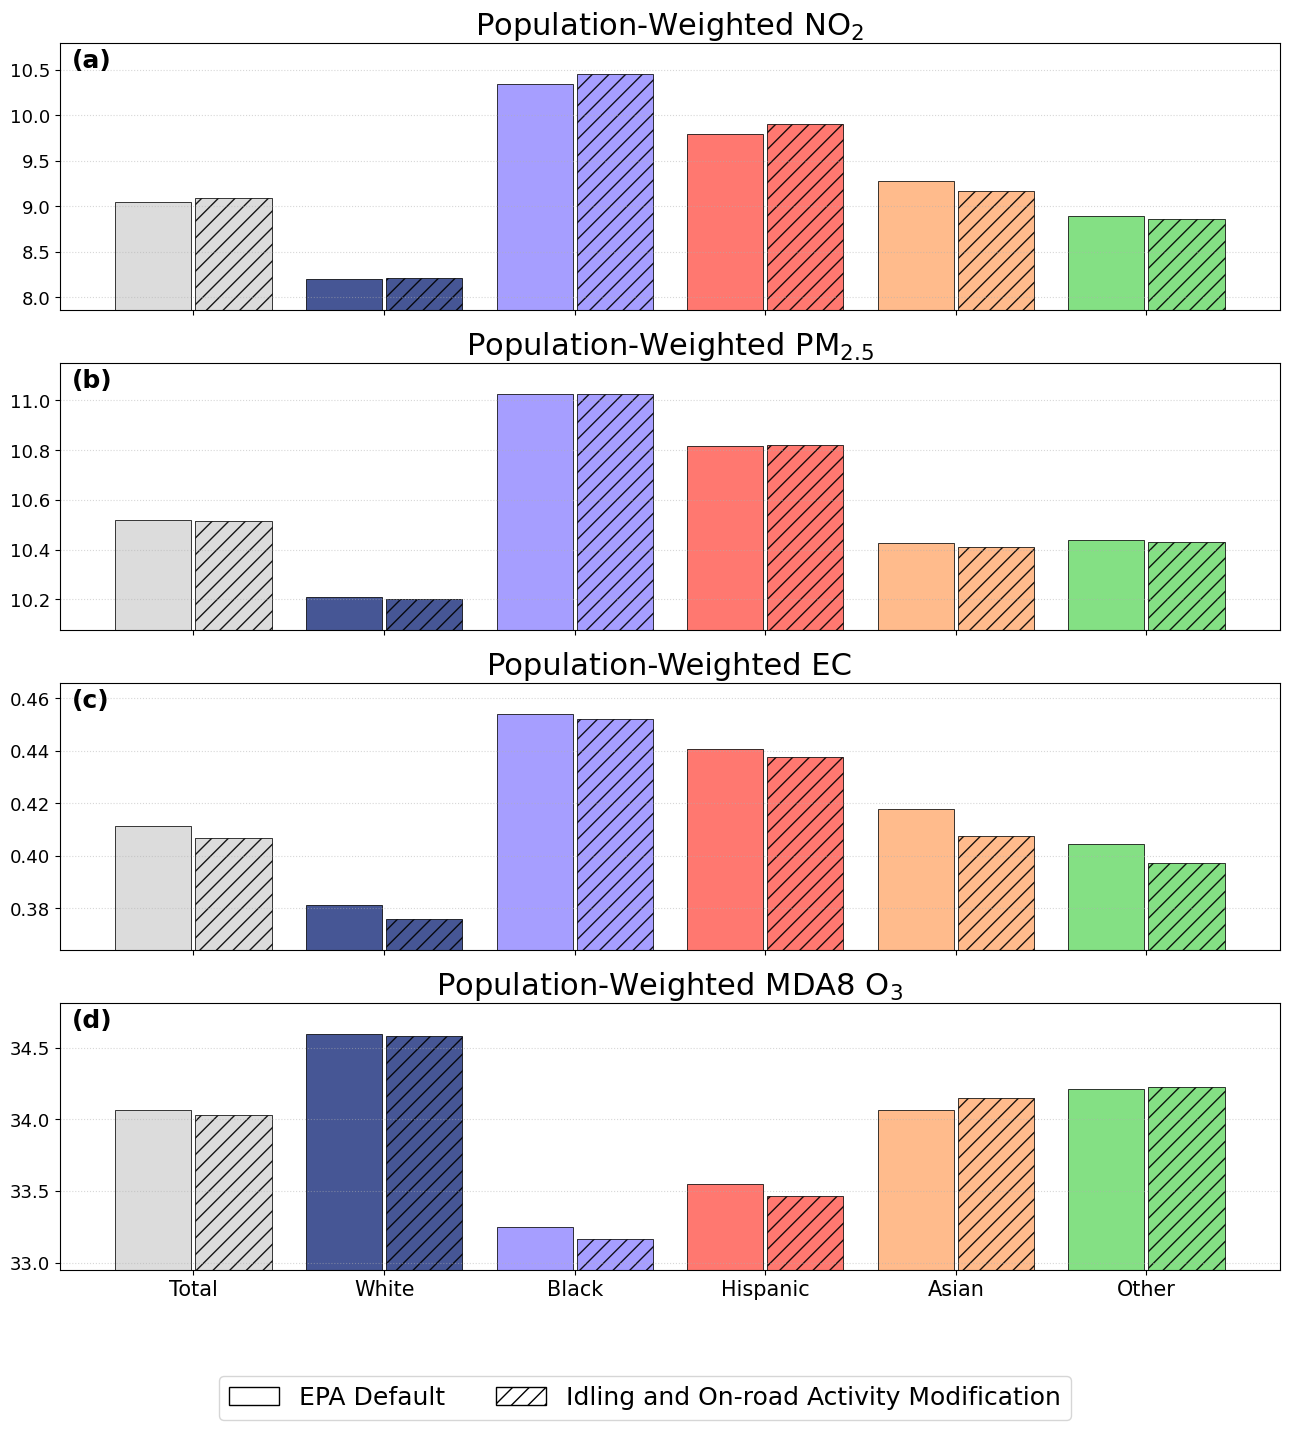

In [33]:
fig, axes = plt.subplots(4, 1, figsize=(13, 15), sharex=True)

labels = ["(a)", "(b)", "(c)", "(d)"]

x = np.arange(len(subgroups_for_plot))
cluster_w = 0.84
bar_w = cluster_w / len(scenario_keys)
offsets = (np.arange(len(scenario_keys)) - (len(scenario_keys) - 1) / 2) * bar_w


# zoom y-axis to plotted values
def set_zoomed_ylim(ax, values, padding=0.15):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]

    ymin, ymax = vals.min(), vals.max()
    data_range = ymax - ymin

    if data_range == 0:
        data_range = abs(ymax) * 0.05 if ymax != 0 else 1

    pad = data_range * padding
    ax.set_ylim(ymin - pad, ymax + pad)


# plot settings
plot_data = [
    (no2_vals, "Population-Weighted NO$_2$"),
    (pm25tot_vals, "Population-Weighted PM$_{2.5}$"),
    (pm25ec_vals, "Population-Weighted EC"),
    (o3_vals, "Population-Weighted MDA8 O$_3$")
]


# plot each pollutant
for ax, (vals, title), panel_label in zip(axes, plot_data, labels):

    for s, key in enumerate(scenario_keys):
        for i, g in enumerate(subgroups_for_plot):
            ax.bar(x[i] + offsets[s], vals[s, i], width=bar_w * 0.95, color=colors_for_plot[g], hatch=hatches[key], edgecolor="black", linewidth=0.6, alpha=0.9)

    ax.set_title(title, fontsize=22)
    ax.text(0.01, 0.98, panel_label, transform=ax.transAxes, fontsize=18, fontweight="bold", va="top", ha="left")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.tick_params(axis="y", labelsize=13)

    set_zoomed_ylim(ax, vals, padding=0.15)


# x-axis
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(subgroups_for_plot, fontsize=15)


# scenario legend
scenario_patches = [
    mpatches.Patch(facecolor="white", edgecolor="black", hatch=hatches[k], label=scenario_labels[i])
    for i, k in enumerate(scenario_keys)
]

fig.legend(handles=scenario_patches, fontsize=18, loc="lower center", ncol=2, frameon=True)


# save
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.savefig("Annual_PWConcentrations_Zoomed.png", dpi=300, bbox_inches="tight")
plt.show()

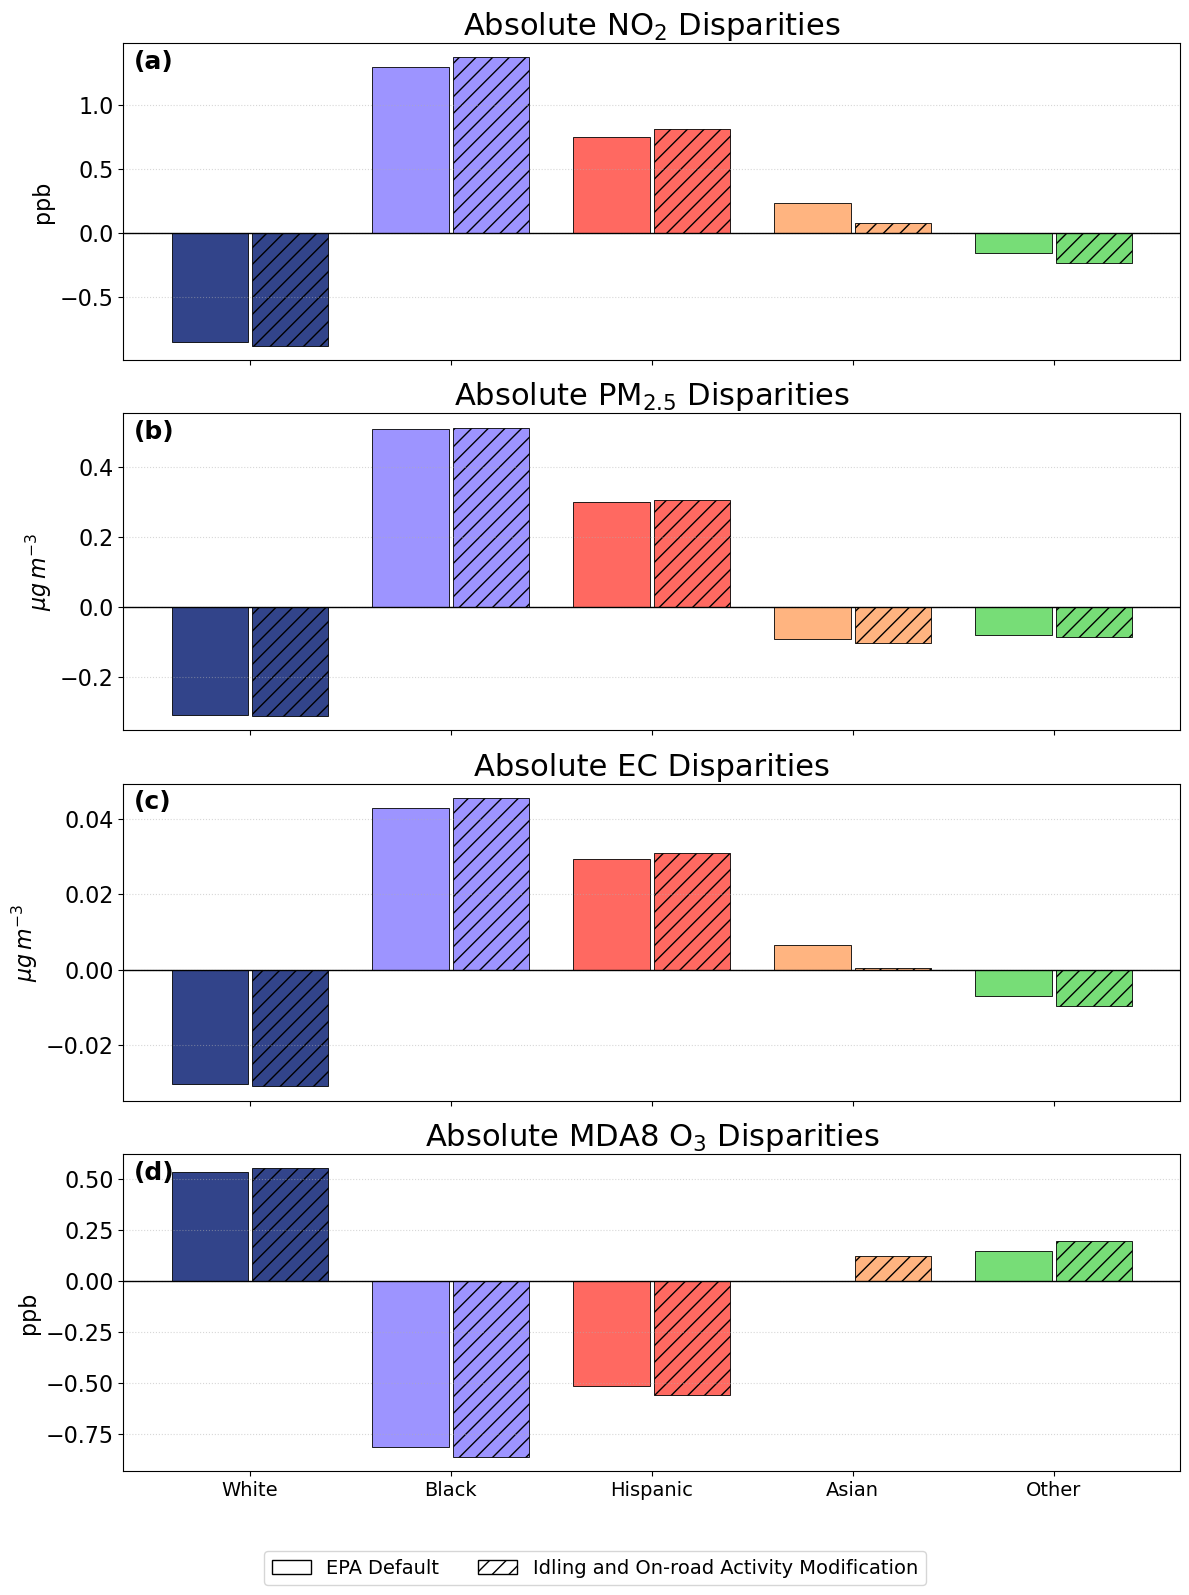

In [34]:
subgroups = ["White", "Black", "Hispanic", "Asian", "Other"]

scenario_keys = ["Base", "Idling"]
scenario_labels = ["EPA Default", "Idling and On-road Activity Modification"]

colors = {
    "White": "#32448A",
    "Black": "#9d94ff",
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Other": "#77dd77",
}

hatches = {"Base": "", "Idling": "//"}
labels = ["(a)", "(b)", "(c)", "(d)"]

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

x = np.arange(len(subgroups))
cluster_w = 0.8
bar_w = cluster_w / len(scenario_keys)
offsets = (np.arange(len(scenario_keys)) - (len(scenario_keys) - 1) / 2) * bar_w


# plot settings
plot_data = [
    (no2_summary, "Absolute NO$_2$ Disparities", "ppb"),
    (pm25_tot_summary, "Absolute PM$_{2.5}$ Disparities", r"$\mu g \, m^{-3}$"),
    (pm25_ec_summary, "Absolute EC Disparities", r"$\mu g \, m^{-3}$"),
    (O3_summary, "Absolute MDA8 O$_3$ Disparities", "ppb"),
]


# plot each pollutant
for ax, (summary, title, ylabel), panel_label in zip(axes, plot_data, labels):

    for s, key in enumerate(scenario_keys):
        for i, g in enumerate(subgroups):
            ax.bar(x[i] + offsets[s], summary.loc[g, f"{key}_Absolute"], width=bar_w * 0.95,
                   color=colors[g], hatch=hatches[key], edgecolor="black", linewidth=0.6)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title, fontsize=22)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.text(0.01, 0.98, panel_label, transform=ax.transAxes, fontsize=18, fontweight="bold", va="top", ha="left")
    ax.tick_params(axis="y", labelsize=16)
    ax.grid(axis="y", linestyle=":", alpha=0.5)


# x-axis
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(subgroups, fontsize=14)


# scenario legend
scenario_patches = [
    mpatches.Patch(facecolor="white", edgecolor="black", hatch=hatches[k], label=scenario_labels[i])
    for i, k in enumerate(scenario_keys)
]

fig.legend(handles=scenario_patches, loc="lower center", ncol=2, fontsize=14, frameon=True)


# save
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("AnnualizedEpaDefault_LOCUS_ConcentrationsAbsoluteDisparities.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
# population counts
total_pop = full_merged["ASOAE001"]

full_merged["Hispanic_pop"] = full_merged["ASOAE012"]
full_merged["Asian_pop"] = full_merged["ASOAE006"]
full_merged["Black_pop"] = full_merged["ASOAE004"]
full_merged["White_pop"] = full_merged["ASOAE003"]

# remaining population
full_merged["Other_pop"] = (total_pop - full_merged["Hispanic_pop"] - full_merged["Asian_pop"] - full_merged["Black_pop"] - full_merged["White_pop"]).clip(lower=0)

# convert to tract-level percentages
full_merged["Prc_Hispanic"] = full_merged["Hispanic_pop"] / total_pop * 100
full_merged["Prc_Asian"] = full_merged["Asian_pop"] / total_pop * 100
full_merged["Prc_Black"] = full_merged["Black_pop"] / total_pop * 100
full_merged["Prc_White"] = full_merged["White_pop"] / total_pop * 100
full_merged["Prc_Other"] = full_merged["Other_pop"] / total_pop * 100

# remove values from zero-population tracts
race_percent_columns = ["Prc_Hispanic", "Prc_Asian", "Prc_Black", "Prc_White", "Prc_Other"]
full_merged[race_percent_columns] = full_merged[race_percent_columns].replace([np.inf, -np.inf], np.nan)

In [50]:
# race/ethnicity columns
race_columns = {
    "Hispanic": "Prc_Hispanic",
    "Asian": "Prc_Asian",
    "Black": "Prc_Black",
    "White": "Prc_White",
    "Other": "Prc_Other"
}

race_colors = {
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Black": "#59adf6",
    "White": "#32448A",
    "Other": "#9d94ff"
}

pollutants = {
    "NO$_2$": ("base_NO2", "locus_NO2"),
    "PM$_{2.5}$": ("base_PM25_TOT", "locus_PM25_TOT"),
    "EC": ("base_PM25_EC", "locus_PM25_EC"),
    "MDA8 O$_3$": ("base_O3", "locus_O3")
}

race_colors = {
    "Hispanic": "#ff6961",
    "Asian": "#ffb480",
    "Black": "#59adf6",
    "White": "#32448A",
    "Other": "#9d94ff"
}

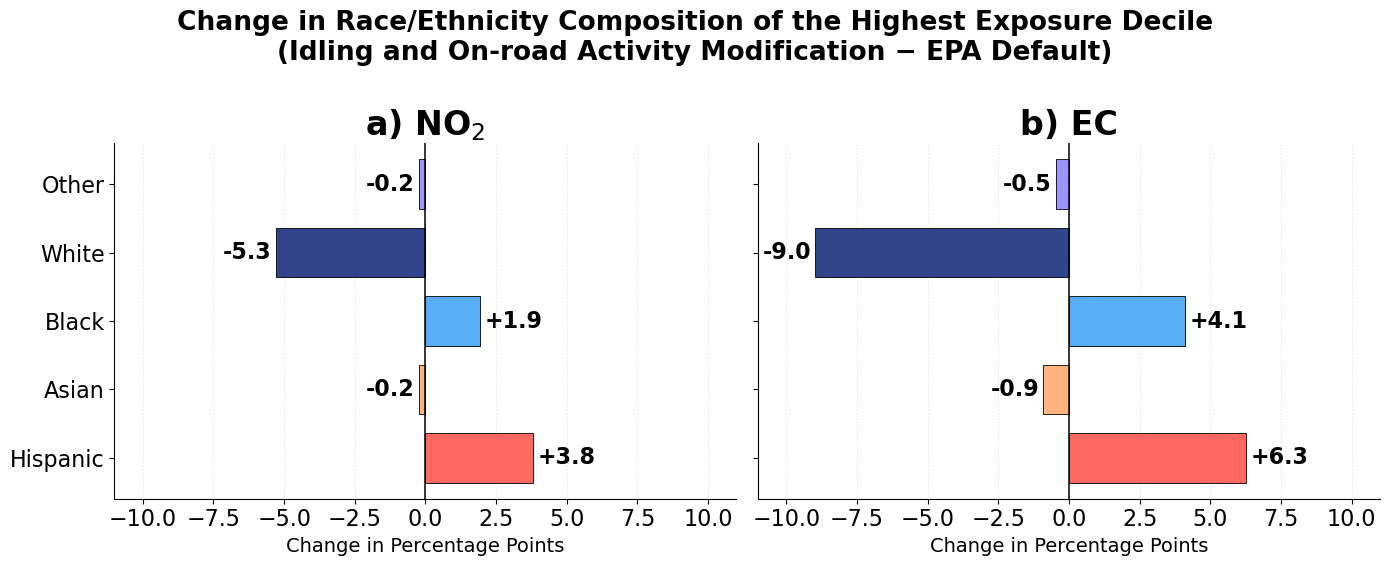

In [51]:
race_order = ["Hispanic", "Asian", "Black", "White", "Other"]


# pollutant columns
pollutants = {
    "NO$_2$": ("base_NO2", "locus_NO2"),
    "EC": ("base_PM25_EC", "locus_PM25_EC")
}


# calculate race/ethnicity composition of the 10th exposure decile
def get_top_decile(df, concentration_column):

    valid = df[concentration_column].notna() & np.isfinite(df[concentration_column]) & (df["ASOAE001"] > 0)

    decile = pd.Series(np.nan, index=df.index)
    decile.loc[valid] = pd.qcut(df.loc[valid, concentration_column].rank(method="first"), 10, labels=False) + 1

    return df.loc[decile == 10, list(race_columns.values())].mean()


# calculate modification minus EPA Default
top_decile_changes = {}

for pollutant, (base_col, locus_col) in pollutants.items():

    base = get_top_decile(full_merged, base_col)
    locus = get_top_decile(full_merged, locus_col)

    changes = locus - base
    changes.index = race_order

    top_decile_changes[pollutant] = changes


# plot NO2 and EC
selected_pollutants = ["NO$_2$", "EC"]
panel_labels = ["a)", "b)"]

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)

for ax, pollutant, panel in zip(axs, selected_pollutants, panel_labels):

    changes = top_decile_changes[pollutant].reindex(race_order)
    y = np.arange(len(race_order))

    ax.barh(y, changes.values, color=[race_colors[r] for r in race_order], edgecolor="black", linewidth=0.6, height=0.72)
    ax.axvline(0, color="black", linewidth=1.1)

    # label change
    for yi, value in zip(y, changes.values):
        ax.text(value + (0.15 if value >= 0 else -0.15), yi, f"{value:+.1f}",
                ha="left" if value >= 0 else "right", va="center", fontsize=16, fontweight="bold")

    ax.set_yticks(y)
    ax.set_yticklabels(race_order, fontsize=16)
    ax.invert_yaxis()
    ax.set_xlim(-11, 11)
    ax.set_title(f"{panel} {pollutant}", fontsize=24, fontweight="bold")
    ax.set_xlabel("Change in Percentage Points", fontsize=14)
    ax.tick_params(axis="x", labelsize=16)
    ax.grid(axis="x", linestyle=":", alpha=0.35)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# title
fig.suptitle(
    "Change in Race/Ethnicity Composition of the Highest Exposure Decile\n"
    "(Idling and On-road Activity Modification − EPA Default)",
    fontsize=19,
    fontweight="bold",
    y=1.02
)


# save
plt.tight_layout()
plt.savefig("Top_Decile_NO2_EC_Diverging_Bars.png", dpi=300, bbox_inches="tight")
plt.savefig("Top_Decile_NO2_EC_Diverging_Bars.pdf", dpi=300, bbox_inches="tight")
plt.show()

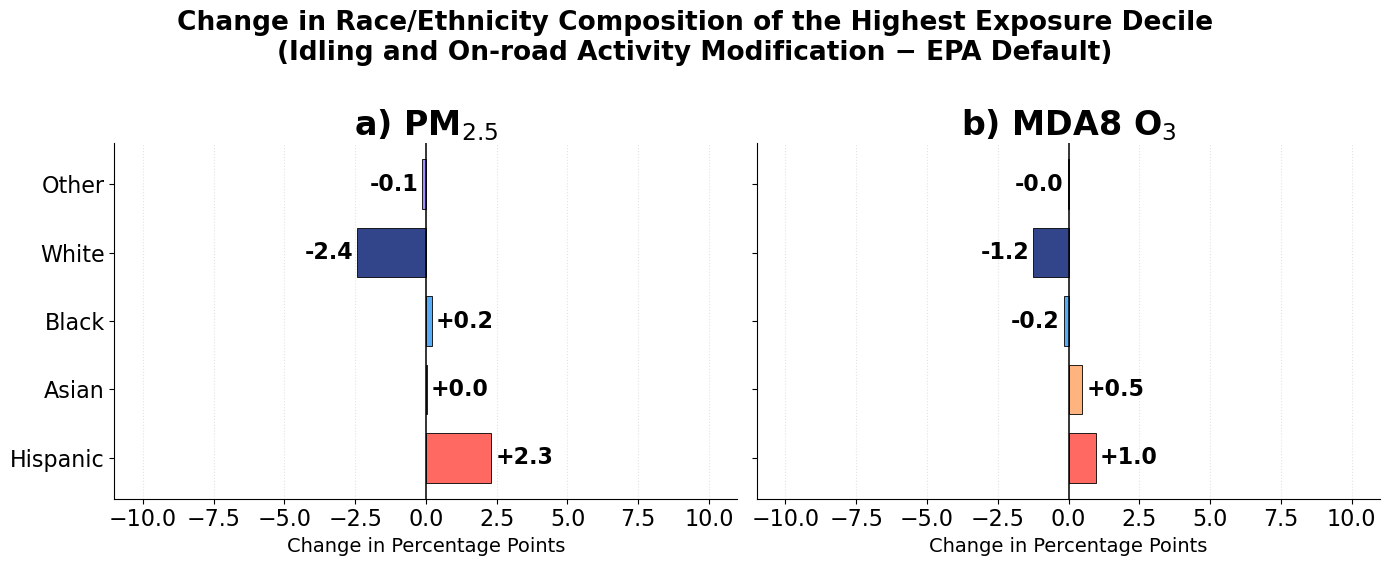

In [52]:
# pollutant columns
pollutants = {
    "PM$_{2.5}$": ("base_PM25_TOT", "locus_PM25_TOT"),
    "MDA8 O$_3$": ("base_O3", "locus_O3")
}


# calculate modification minus EPA Default
top_decile_changes = {}

for pollutant, (base_col, locus_col) in pollutants.items():

    base = get_top_decile(full_merged, base_col)
    locus = get_top_decile(full_merged, locus_col)

    changes = locus - base
    changes.index = race_order

    top_decile_changes[pollutant] = changes


# plot PM2.5 and MDA8 O3
selected_pollutants = ["PM$_{2.5}$", "MDA8 O$_3$"]
panel_labels = ["a)", "b)"]

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)

for ax, pollutant, panel in zip(axs, selected_pollutants, panel_labels):

    changes = top_decile_changes[pollutant].reindex(race_order)
    y = np.arange(len(race_order))

    ax.barh(y, changes.values, color=[race_colors[r] for r in race_order], edgecolor="black", linewidth=0.6, height=0.72)
    ax.axvline(0, color="black", linewidth=1.1)

    # label change
    for yi, value in zip(y, changes.values):
        ax.text(value + (0.15 if value >= 0 else -0.15), yi, f"{value:+.1f}",
                ha="left" if value >= 0 else "right", va="center", fontsize=16, fontweight="bold")

    ax.set_yticks(y)
    ax.set_yticklabels(race_order, fontsize=16)
    ax.invert_yaxis()
    ax.set_xlim(-11, 11)
    ax.set_title(f"{panel} {pollutant}", fontsize=24, fontweight="bold")
    ax.set_xlabel("Change in Percentage Points", fontsize=14)
    ax.tick_params(axis="x", labelsize=16)
    ax.grid(axis="x", linestyle=":", alpha=0.35)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# title
fig.suptitle(
    "Change in Race/Ethnicity Composition of the Highest Exposure Decile\n"
    "(Idling and On-road Activity Modification − EPA Default)",
    fontsize=19,
    fontweight="bold",
    y=1.02
)


# save
plt.tight_layout()
plt.savefig("Top_Decile_PM25_O3_Diverging_Bars.png", dpi=300, bbox_inches="tight")
plt.savefig("Top_Decile_PM25_O3_Diverging_Bars.pdf", dpi=300, bbox_inches="tight")
plt.show()

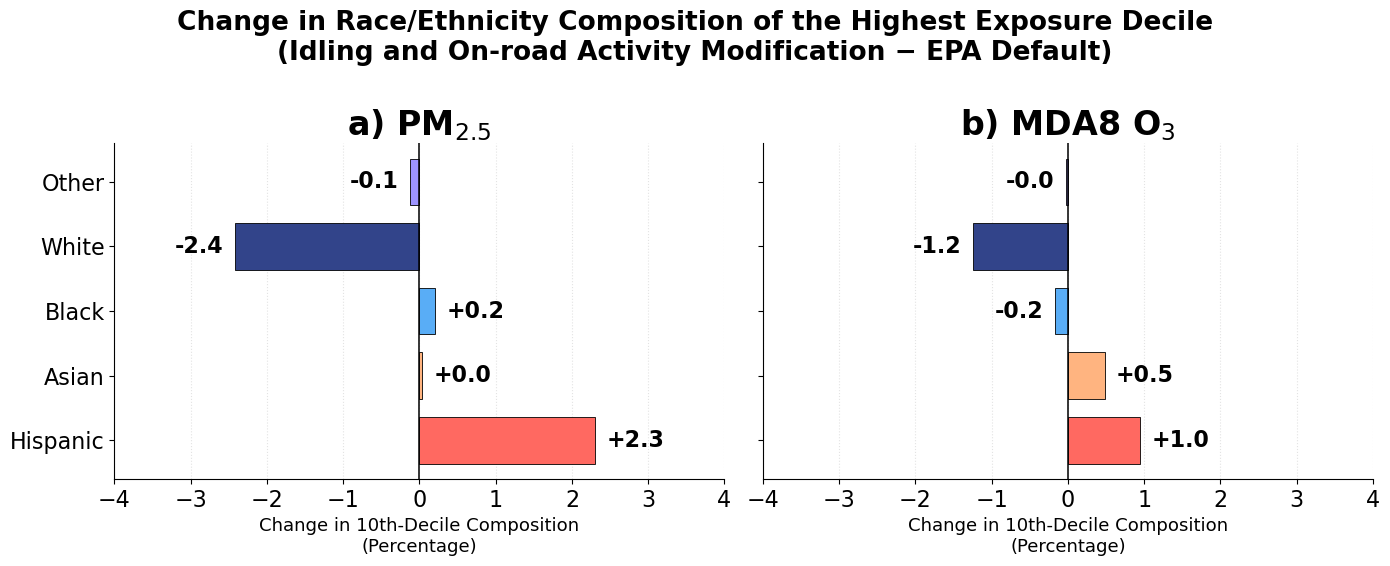

In [48]:
# ============================================================
# DIVERGING BARS: CHANGE IN 10TH-DECILE COMPOSITION
# PM2.5 AND MDA8 O3 ONLY
# Idling and On-road Activity Modification minus EPA Default
# ============================================================

selected_pollutants = ["PM$_{2.5}$", "MDA8 O$_3$"]

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
axs = np.atleast_1d(axs).flatten()

panel_labels = ["a)", "b)"]
race_order = ["Hispanic", "Asian", "Black", "White", "Other"]

selected_results = {
    pollutant_name: top_decile_results[pollutant_name]
    for pollutant_name in selected_pollutants
}

all_changes = []
for table in selected_results.values():
    changes = table["Idling and On-road Activity Modification"] - table["EPA Default"]
    all_changes.extend(changes.values)

x_limit = np.ceil(np.max(np.abs(all_changes))) + 1

for panel_index, (pollutant_name, table) in enumerate(selected_results.items()):
    ax = axs[panel_index]

    changes = (
        table["Idling and On-road Activity Modification"]
        - table["EPA Default"]
    ).reindex(race_order)

    y = np.arange(len(race_order))
    bar_colors = [race_colors[race] for race in race_order]

    ax.barh(
        y,
        changes.values,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.6,
        height=0.72
    )

    ax.axvline(0, color="black", linewidth=1.1)

    for yi, value in zip(y, changes.values):
        if value >= 0:
            ax.text(
                value + 0.15,
                yi,
                f"+{value:.1f}",
                ha="left",
                va="center",
                fontsize=16,
                fontweight="bold"
            )
        else:
            ax.text(
                value - 0.15,
                yi,
                f"{value:.1f}",
                ha="right",
                va="center",
                fontsize=16,
                fontweight="bold"
            )

    ax.set_yticks(y)
    ax.set_yticklabels(race_order, fontsize=16)
    ax.invert_yaxis()
    ax.set_xlim(-x_limit, x_limit)
    ax.set_title(
        f"{panel_labels[panel_index]} {pollutant_name}",
        fontsize=24,
        fontweight="bold"
    )
    ax.set_xlabel(
        "Change in 10th-Decile Composition\n(Percentage)",
        fontsize=13
    )
    ax.tick_params(axis="x", labelsize=16)
    ax.grid(axis="x", linestyle=":", alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Change in Race/Ethnicity Composition of the Highest Exposure Decile\n"
    "(Idling and On-road Activity Modification − EPA Default)",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
# plt.savefig("Top_Decile_PM25_O3_Diverging_Bars.png", dpi=300, bbox_inches="tight")
# plt.savefig("Top_Decile_PM25_O3_Diverging_Bars.pdf", dpi=300, bbox_inches="tight")
plt.show()